In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option('display.max_columns',None)

In [6]:
df = pd.read_csv('/Users/garvit/Desktop/NestWise/4 - EDA/gurgaon_properties_missing_value_imputation.csv')
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,tulip ivory3.,sector 70,2.00,8333.0,4.0,5.0,3+,6.0,Moderately Old,2114.0,0,1,0,0,0,1,95
1,flat,capital residences 360,sector 70a,1.69,8553.0,3.0,3.0,3+,8.0,New Property,1900.0,0,1,0,0,0,0,165
2,flat,emaar palm premier,sector 77,2.10,10500.0,3.0,4.0,3+,11.0,New Property,1600.0,0,1,0,0,0,1,129
3,flat,m3m merlin3.,sector 67,2.65,12946.0,3.0,3.0,3,0.0,Relatively New,2047.0,0,0,0,0,1,1,174
4,flat,dnha group housing society,manesar,0.75,4518.0,3.0,2.0,2,5.0,Moderately Old,1502.0,0,0,0,0,0,0,0


In [7]:
df.shape

(3568, 18)

# for base line model

we will be dropping price_per_sqft, strong colinearity with price, 2nd we will be asking the user for just the price, not price_per_sqft so, it won't matter 
also, dropping society, if the user already know in which society he/she wants a flat to they can simply go there




In [9]:
train_df =  df.drop(columns = ['society','price_per_sqft'])

In [10]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 70,2.00,4.0,5.0,3+,6.0,Moderately Old,2114.0,0,1,0,0,0,1,95
1,flat,sector 70a,1.69,3.0,3.0,3+,8.0,New Property,1900.0,0,1,0,0,0,0,165
2,flat,sector 77,2.10,3.0,4.0,3+,11.0,New Property,1600.0,0,1,0,0,0,1,129
3,flat,sector 67,2.65,3.0,3.0,3,0.0,Relatively New,2047.0,0,0,0,0,1,1,174
4,flat,manesar,0.75,3.0,2.0,2,5.0,Moderately Old,1502.0,0,0,0,0,0,0,0


### now our aim is find/select feature which accurately/closely justify the price, i.e we need feature selection

# luxury score

-> since it's our feature, our model don't know what 50 score means or what 120 score means, rather what we can do is make this numerical col categorical so. "low luxury", "medium luxury" and "high luxury"

<Axes: xlabel='luxury_score'>

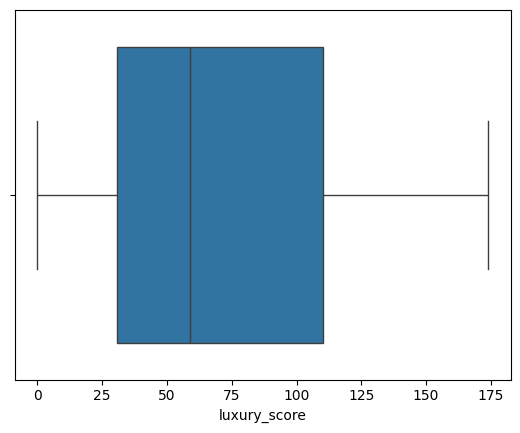

In [11]:
sns.boxplot(x=df['luxury_score'])

In [13]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score <150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None

In [14]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [15]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 70,2.00,4.0,5.0,3+,6.0,Moderately Old,2114.0,0,1,0,0,0,1,95,Medium
1,flat,sector 70a,1.69,3.0,3.0,3+,8.0,New Property,1900.0,0,1,0,0,0,0,165,High
2,flat,sector 77,2.10,3.0,4.0,3+,11.0,New Property,1600.0,0,1,0,0,0,1,129,Medium
3,flat,sector 67,2.65,3.0,3.0,3,0.0,Relatively New,2047.0,0,0,0,0,1,1,174,High
4,flat,manesar,0.75,3.0,2.0,2,5.0,Moderately Old,1502.0,0,0,0,0,0,0,0,Low


### similarly we can do this for floor, we wont' be asking the user on which floor they want a flat/appartment, rather we can have category as "Low floor", "Mid Floor" and "High Floor"

<Axes: xlabel='floorNum'>

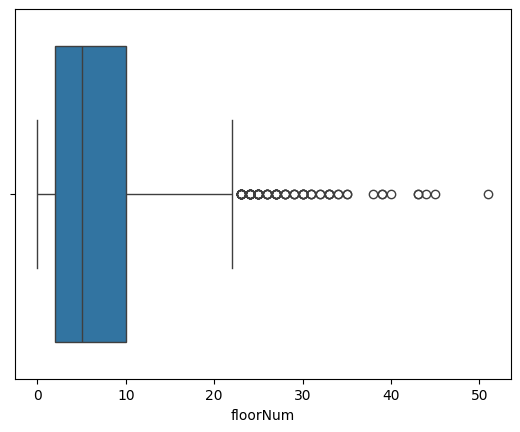

In [16]:
sns.boxplot(x=df['floorNum'])

In [17]:
def categorize_floor(floor):
    if 0<= floor <=2 :
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None

In [18]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [19]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 70,2.00,4.0,5.0,3+,6.0,Moderately Old,2114.0,0,1,0,0,0,1,95,Medium,Mid Floor
1,flat,sector 70a,1.69,3.0,3.0,3+,8.0,New Property,1900.0,0,1,0,0,0,0,165,High,Mid Floor
2,flat,sector 77,2.10,3.0,4.0,3+,11.0,New Property,1600.0,0,1,0,0,0,1,129,Medium,High Floor
3,flat,sector 67,2.65,3.0,3.0,3,0.0,Relatively New,2047.0,0,0,0,0,1,1,174,High,Low Floor
4,flat,manesar,0.75,3.0,2.0,2,5.0,Moderately Old,1502.0,0,0,0,0,0,0,0,Low,Mid Floor


In [20]:
train_df.drop(columns = ['floorNum','luxury_score'],inplace=True)

In [21]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 70,2.00,4.0,5.0,3+,Moderately Old,2114.0,0,1,0,0,0,1,Medium,Mid Floor
1,flat,sector 70a,1.69,3.0,3.0,3+,New Property,1900.0,0,1,0,0,0,0,High,Mid Floor
2,flat,sector 77,2.10,3.0,4.0,3+,New Property,1600.0,0,1,0,0,0,1,Medium,High Floor
3,flat,sector 67,2.65,3.0,3.0,3,Relatively New,2047.0,0,0,0,0,1,1,High,Low Floor
4,flat,manesar,0.75,3.0,2.0,2,Moderately Old,1502.0,0,0,0,0,0,0,Low,Mid Floor
